In [1]:
import matplotlib.pyplot as plt
import numpy as np
from galpy.util import conversion
import astropy.units as u
from galpy.potential import (
    MWPotential2014, 
    vcirc,
    evaluateDensities,
    mass,
    HernquistPotential,
    NFWPotential,
    interpSphericalPotential,
    ChandrasekharDynamicalFrictionForce,
    MovingObjectPotential,
    NonInertialFrameForce,
    evaluateRforces,
    evaluatezforces,
    evaluatephitorques
    )
from galpy.orbit import Orbit
from galpy.df import (
    isotropicHernquistdf,
    constantbetaHernquistdf)
from scipy.optimize import minimize
import os
import ctypes
import time

os.environ["OMP_NUM_THREADS"] = "8"
omp = ctypes.CDLL('vcomp140.dll')

ro, vo = 8.0 * u.kpc, 220.0 * u.km / u.s
R0 = 8.0 * u.kpc

MWPotential2014.turn_physical_on(ro=ro,vo=vo)

##Exercise 1

####1. and 3.

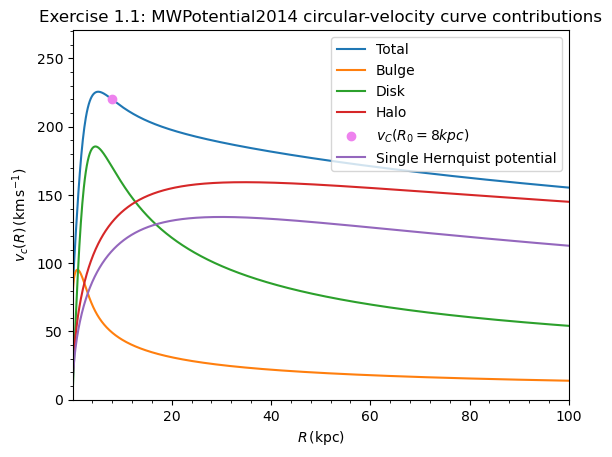

In [2]:
# get each component

bulge = MWPotential2014[0]
disk = MWPotential2014[1]
halo = MWPotential2014[2]

# get each component's vcirc plot in physical units
MWPotential2014.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    use_physical=True,
    label="Total")

bulge.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    use_physical=True,
    overplot=True,
    label="Bulge")

disk.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    grid=1001,
    use_physical=True,
    overplot=True,
    label="Disk")
  
halo.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    grid=1001,
    use_physical=True,
    overplot=True,
    label="Halo")
        

# find circular velocity at R0 = 8kpc
V0 = vcirc(MWPotential2014, R0.value/ro.value, ro=ro.value, vo=vo.value)
plt.scatter(R0.value, V0, label="$v_C(R_0=8kpc)$",color="violet",zorder=5)

# 3. Add single Hernquist

G = 4.30091e-6 
M  = 1e12
hp = HernquistPotential(
    amp=G * M / (vo.value**2 * ro.value),
    a=30/ro.value)

hp.plotRotcurve(
    Rrange=[0.1,100],
    ro=ro.value,
    vo=vo.value,
    grid=1001,
    use_physical=True,
    overplot=True,
    label="Single Hernquist potential"
    )

plt.legend()
plt.title("Exercise 1.1: MWPotential2014 circular-velocity curve contributions")

plt.show()

####2.

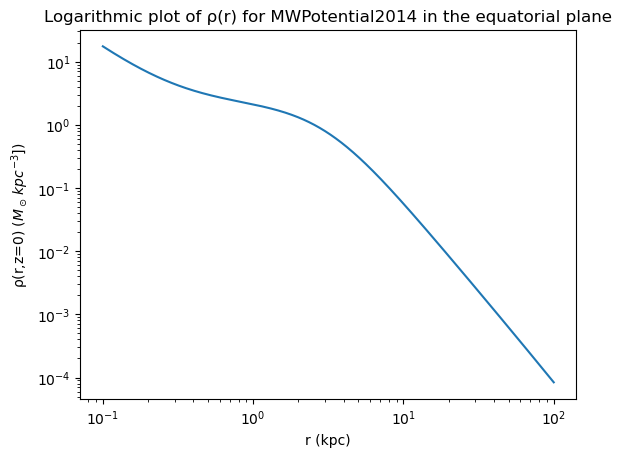

In [3]:
# Density plot
# make an r array from 10e-1 to 10e2 (0.1 to 100kpc)
r = np.logspace(-1,2,500)

# get r in galpy units
r_galpy = r/ro.value

rho = np.array([evaluateDensities(
    MWPotential2014,
    R,
    0.0,
    ro=ro.value,
    vo=vo.value,
    use_physical=True) 
    for R in r_galpy]) 
    
plt.loglog(r, rho)

plt.title("Logarithmic plot of ρ(r) for MWPotential2014 in the equatorial plane")
plt.xlabel("r (kpc)")
plt.ylabel("ρ(r,z=0) ($M_\odot\,{kpc}^{-3}]$)")

plt.show()

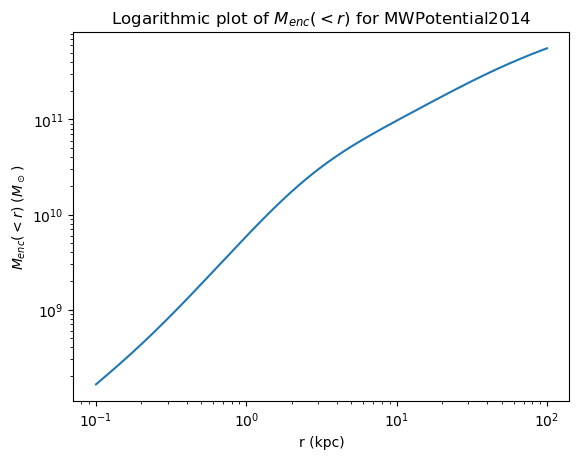

In [4]:
# Mass plot
menc = np.array([mass(
    MWPotential2014,
    R,
    ro=ro.value,
    vo=vo.value,
    use_physical=True,)
    for R in r_galpy])
    
plt.loglog(r, menc)

plt.title("Logarithmic plot of $M_{enc}(<r)$ for MWPotential2014")
plt.xlabel("r (kpc)")
plt.ylabel("$M_{enc}(<r)$ $(M_\odot\,{}$)")

plt.show()

##Exercise 2

####1.

In [5]:
o_sun = Orbit()
o_sun.turn_physical_on()

ts = np.linspace(0.0,5.0,10000) * u.Gyr
o_sun.integrate(ts,MWPotential2014)

####2.

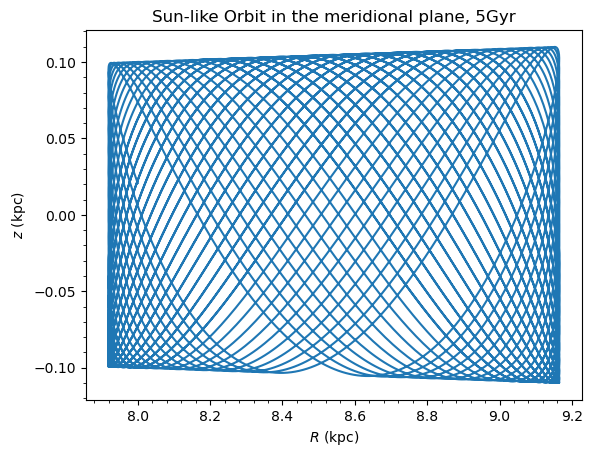

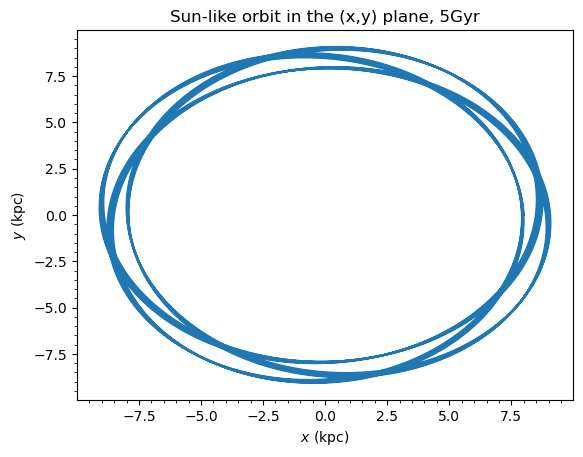

In [6]:
o_sun.plot(d1="R",d2="z")
plt.title("Sun-like Orbit in the meridional plane, 5Gyr")
plt.show()

o_sun.plot(d1="x",d2="y")
plt.title("Sun-like orbit in the (x,y) plane, 5Gyr")
plt.show()

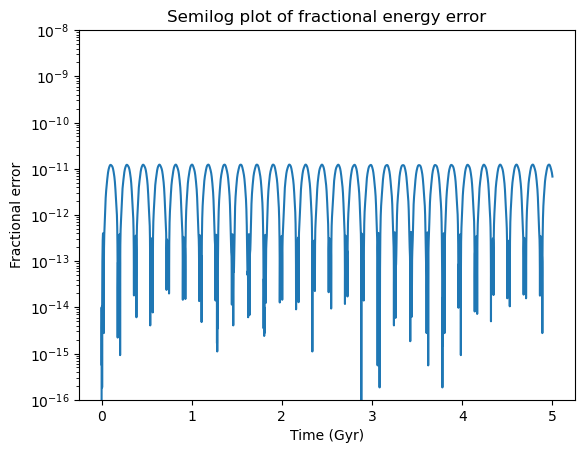

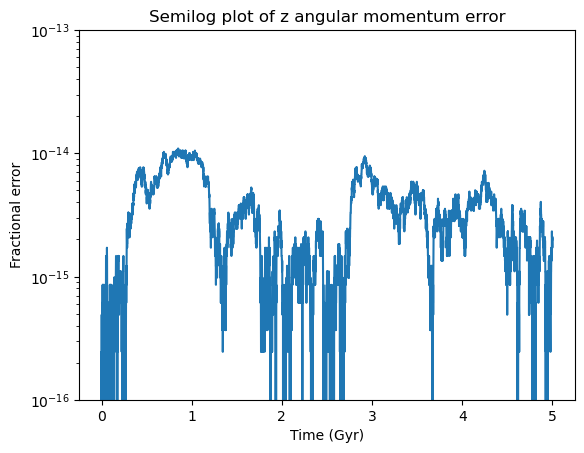

In [7]:
# find the energy and z angular momentum for all times
E = o_sun.E(ts, pot=MWPotential2014, use_physical=True)
Lz = o_sun.Lz(ts, use_physical=True)

# get the initial energy and angular momentum
E0 = E[0]
Lz0 = Lz[0]


# find fractional errors at each time

E_error = np.abs((E - E0) / E0)
Lz_error = np.abs((Lz - Lz0) / Lz0)

plt.semilogy(ts, E_error)
plt.title("Semilog plot of fractional energy error")
plt.xlabel("Time (Gyr)")
plt.ylabel("Fractional error")
plt.ylim(1e-16,1e-8)
plt.show()

plt.semilogy(ts, Lz_error)
plt.title("Semilog plot of z angular momentum error")
plt.xlabel("Time (Gyr)")
plt.ylabel("Fractional error")
plt.ylim(1e-16,1e-13)
plt.show()

These graphs show that the default integrator (symplec4_c) is has an error of around 1e-11 for energy and around 1e-14 for angular momentum (almost machine precision). The errors also seem to remain relatively stable over time.

C:\Users\mylan\AppData\Local\Temp\ipykernel_18084\1284994981.py:19: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e-8)



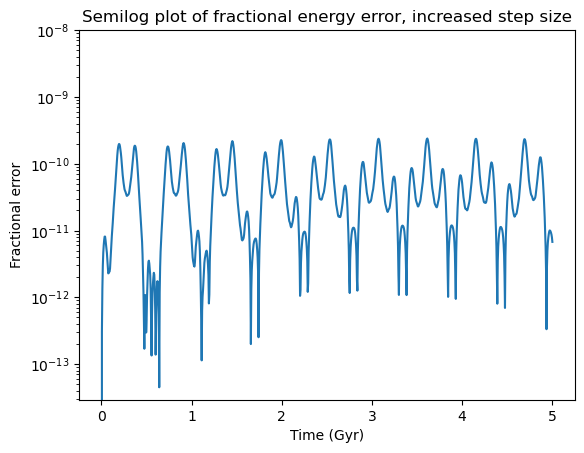

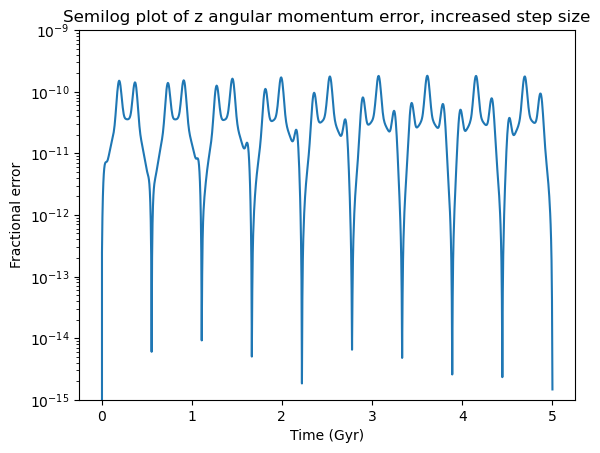

In [8]:
# changing the step size

ts_less = np.linspace(0.0,5.0,1000) * u.Gyr
o_sun.integrate(ts,MWPotential2014)

E = o_sun.E(ts_less, pot=MWPotential2014, use_physical=True)
Lz = o_sun.Lz(ts_less, use_physical=True)

E0 = E[0]
Lz0 = Lz[0]

E_error = np.abs((E - E0) / E0)
Lz_error = np.abs((Lz - Lz0) / Lz0)

plt.semilogy(ts_less, E_error)
plt.title("Semilog plot of fractional energy error, increased step size")
plt.xlabel("Time (Gyr)")
plt.ylabel("Fractional error")
plt.ylim(0,1e-8)
plt.show()

plt.semilogy(ts_less, Lz_error)
plt.title("Semilog plot of z angular momentum error, increased step size")
plt.xlabel("Time (Gyr)")
plt.ylabel("Fractional error")
plt.ylim(1e-15,1e-9)
plt.show()

Increasing the step size increased the error for both energy and z angular momentum.

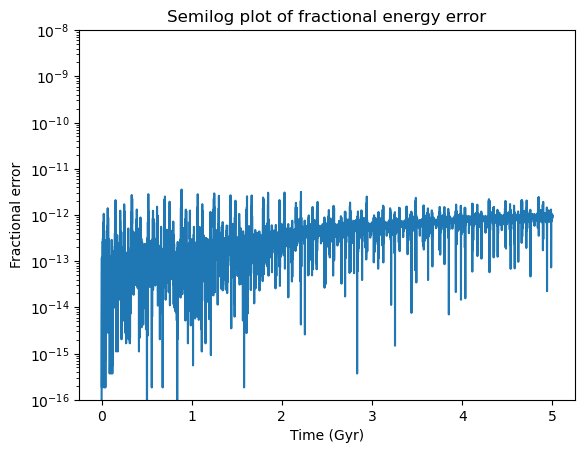

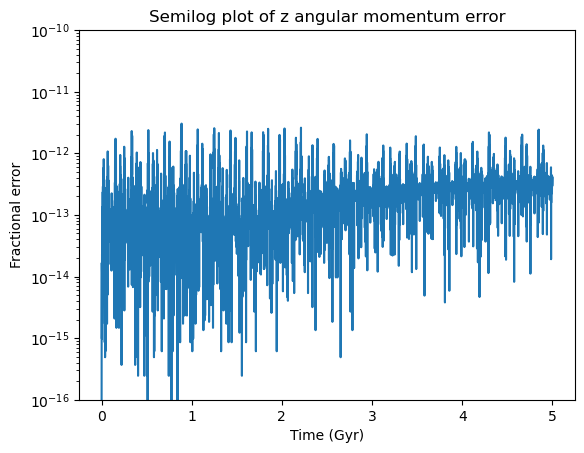

In [9]:
# trying different integration methods

o_sun.integrate(ts,MWPotential2014,method="dop853_c")

# find the energy and z angular momentum for all times
E = o_sun.E(ts, pot=MWPotential2014, use_physical=True)
Lz = o_sun.Lz(ts, use_physical=True)

# get the initial energy and angular momentum
E0 = E[0]
Lz0 = Lz[0]


# find fractional errors at each time

E_error = np.abs((E - E0) / E0)
Lz_error = np.abs((Lz - Lz0) / Lz0)

plt.semilogy(ts, E_error)
plt.title("Semilog plot of fractional energy error")
plt.xlabel("Time (Gyr)")
plt.ylabel("Fractional error")
plt.ylim(1e-16,1e-8)
plt.show()

plt.semilogy(ts, Lz_error)
plt.title("Semilog plot of z angular momentum error")
plt.xlabel("Time (Gyr)")
plt.ylabel("Fractional error")
plt.ylim(1e-16,1e-10)
plt.show()

The errors for the dop853_c method appear to trend upward over time. 

####3.

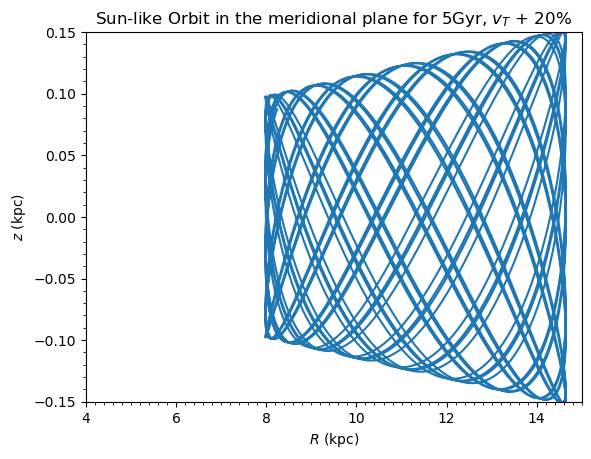

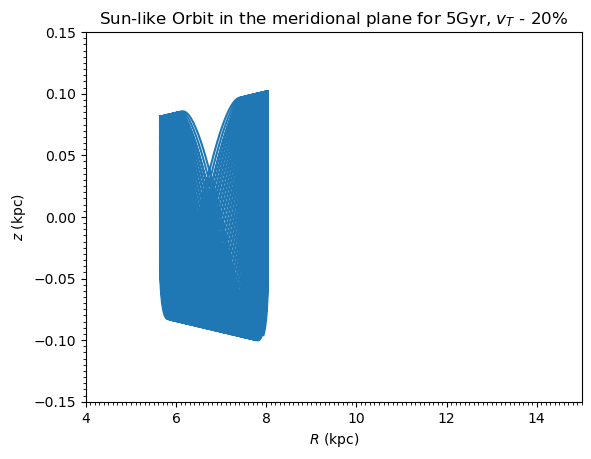

In [10]:
sun_R = 8.0 * u.kpc
sun_vR = -11.1 * u.km / u.s
sun_vT = 232.24 * u.km / u.s
sun_z = 0.0208 * u.kpc
sun_vz = 7.25 * u.km / u.s
sun_phi = 0.0 * u.rad

o_vTplus = Orbit([sun_R,
                  sun_vR,
                  1.2 * sun_vT,
                  sun_z,
                  sun_vz,
                  sun_phi])

o_vTplus.integrate(ts,MWPotential2014)
o_vTplus.plot(d1="R",d2="z")
plt.title("Sun-like Orbit in the meridional plane for 5Gyr, $v_T$ + 20%")
plt.xlim(4,15)
plt.ylim(-0.15,0.15)
plt.show()

o_vTminus = Orbit([sun_R,
                  sun_vR,
                  0.8 * sun_vT,
                  sun_z,
                  sun_vz,
                  sun_phi])

o_vTminus.integrate(ts,MWPotential2014)
o_vTminus.plot(d1="R",d2="z")
plt.title("Sun-like Orbit in the meridional plane for 5Gyr, $v_T$ - 20%")
plt.xlim(4,15)
plt.ylim(-0.15,0.15)
plt.show()


Increasing the initial vT by 20% produced a more radial orbit than lowering it, since the graph of the higher-vT orbit shows a much larger range of R values than the graph of the lower-vT orbit.

##Exercise 3

####1.

In [11]:
# Compute Menc(< r) for MWPotential2014 on a logarithmic grid from 0.1 to 300 kpc

r_grid = np.logspace(np.log10(0.1),np.log10(300),300) * u.kpc

menc_MW = np.array([mass(MWPotential2014, r) for r in r_grid])

####2.

In [12]:
# Find the best-fit (M,a)

def objective(params):
    # use logM and loga as params instead of M and a so they have a more similar scale
    logM, loga = params

    M = 10**logM * u.Msun
    a = 10**loga * u.kpc

    hq = HernquistPotential(amp=M,a=a)

    menc_HQ = mass(hq, r_grid)

    return np.sum((np.log10(menc_HQ) - np.log10(menc_MW))**2)

# set an initial guess (M = 1e12Msun, a = 10 kpc)
guess = [12.0, 1.0]

best_fit = minimize(objective,guess)

best_M = 10**best_fit.x[0]
best_a = 10**best_fit.x[1]

print(f"Best M is {best_M:.4e} Msun")
print(f"Best a is {best_a:.4f} kpc")

Best M is 1.0075e+12 Msun
Best a is 7.9348 kpc


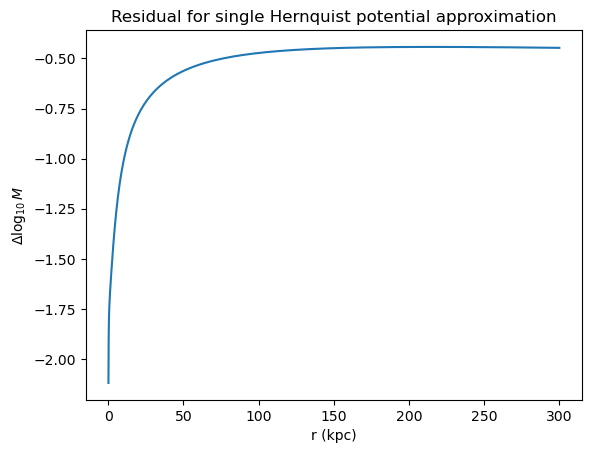

In [13]:
# Plot the residual

hq_best = HernquistPotential(amp=best_M, a=best_a)

menc_HQBest = mass(hq_best,r_grid)
 
residual = np.log10(menc_HQBest) - np.log10(menc_MW)

plt.plot(r_grid,residual)
plt.title("Residual for single Hernquist potential approximation")
plt.xlabel("r (kpc)")
plt.ylabel(r"$\Delta \log_{10} M$")

plt.show()

####3.


In [14]:
# Find the best-fit (M,a)

def objective(params):
    logM_hq, loga_hq, logM_nfw, loga_nfw = params

    # Hernquist (bulge)
    M_hq = 10**logM_hq * u.Msun
    a_hq = 10**loga_hq * u.kpc
    hq = HernquistPotential(amp=M_hq,a=a_hq)
    menc_hq = mass(hq, r_grid)

    # NFW (Halo)
    M_nfw = 10**logM_nfw * u.Msun
    a_nfw = 10**loga_nfw * u.kpc
    nfw = NFWPotential(amp=M_nfw,a=a_nfw)
    menc_nfw = mass(nfw,r_grid)

    menc_total = menc_hq + menc_nfw

    return np.sum((np.log10(menc_total) - np.log10(menc_MW))**2)

# set an initial guess (M = 1e12Msun, a = 10 kpc)
guess = [12.0, 1.0, 12.5, 1.2]

best_fit = minimize(objective,guess)

best_M_hq = 10**best_fit.x[0]
best_a_hq = 10**best_fit.x[1]
best_M_nfw = 10**best_fit.x[2]
best_a_nfw = 10**best_fit.x[3]

print(f"Best Hernquist M is {best_M_hq:.4e} Msun")
print(f"Best Hernquist a is {best_a_hq:.4f} kpc")
print(f"Best NFW M is {best_M_nfw:.4e} Msun")
print(f"Best NFW a is {best_a_nfw:.4f} kpc")

Best Hernquist M is 1.7232e+12 Msun
Best Hernquist a is 55.7652 kpc
Best NFW M is 7.0534e+10 Msun
Best NFW a is 1.7356 kpc


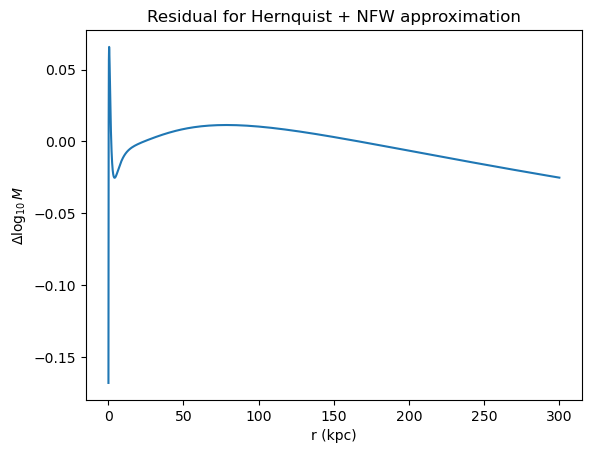

In [15]:
# Plot the residual

hq_component = HernquistPotential(amp=best_M_hq * u.Msun, a=best_a_hq * u.kpc)
menc_hq_component = mass(hq_component,r_grid)

nfw_component = NFWPotential(amp=best_M_nfw * u.Msun, a=best_a_nfw * u.kpc)
menc_nfw_component = mass(nfw_component, r_grid)

menc_total = menc_hq_component + menc_nfw_component
 
residual = np.log10(menc_total) - np.log10(menc_MW)

plt.plot(r_grid,residual)
plt.title("Residual for Hernquist + NFW approximation")
plt.xlabel("r (kpc)")
plt.ylabel(r"$\Delta \log_{10} M$")

plt.show()

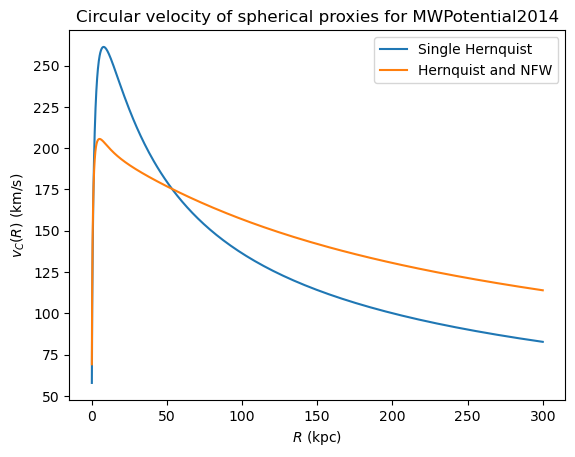

In [16]:
hq_best = HernquistPotential(amp=best_M * u.Msun, a=best_a * u.kpc)
hq_vcirc = hq_best.vcirc(r_grid)
combined_potential = HernquistPotential(amp=best_M_hq * u.Msun, a=best_a_hq * u.kpc) \
    + NFWPotential(amp=best_M_nfw * u.Msun, a=best_a_nfw * u.kpc) 

combined_vcirc = combined_potential.vcirc(r_grid)

plt.plot(r_grid,hq_vcirc,label="Single Hernquist")
plt.plot(r_grid,combined_vcirc,label="Hernquist and NFW")
plt.xlabel("$R$ (kpc)")
plt.ylabel("$v_C(R)$ (km/s)")
plt.title("Circular velocity of spherical proxies for MWPotential2014")
plt.legend()
plt.show()


####4.

In [17]:
r_grid = np.geomspace(0.001, 10000, 500) / ro.value  # kpc -> internal galpy units
r_grid_phys = np.geomspace(0.001, 10000, 500) * u.kpc # in kpc

mw_interp = interpSphericalPotential(MWPotential2014, r_grid)

vc_actual = MWPotential2014.vcirc(r_grid_phys)
vc_interp = mw_interp.vcirc(r_grid_phys)

percent_error = (np.abs(vc_actual - vc_interp) / vc_actual) * 100

max_err = np.max(np.abs(percent_error))
print("Max percent error:", max_err)

Max percent error: 4.3548840005761015e-14


##Exercise 4

####1.

In [18]:
hq_df = isotropicHernquistdf(pot=hq_best)
N = 10**4
orbits = hq_df.sample(n=N,return_orbit=True)

####2.

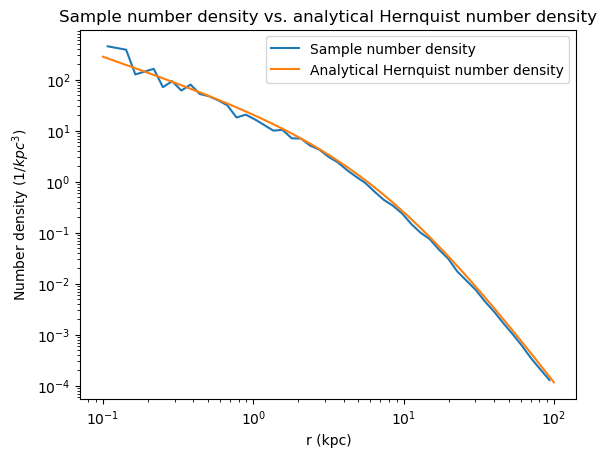

In [19]:
# Sample number density
# get r for each orbit (kpc)
r_samples = orbits.r(use_physical=True)
r_min, r_max = 0.1, 100.0 
bins = np.logspace(np.log10(r_min),np.log10(r_max),50)
counts, edges = np.histogram(r_samples, bins=bins)

r_centres = 0.5*(edges[:-1] + edges[1:])
volumes = (4.0/3.0)*np.pi*(edges[1:]**3 - edges[:-1]**3) # kpc^3

n_sample = counts / volumes # number of particles per spherical shell (kpc^-3)

# Hernquist number density
# formula : rho_Hernquist(r) = M / (2*pi) * a / r(r+a)^3

M_total = best_M # Msun
a = best_a # kpc 

def rho_hern(r,M,a):
    return M * (2.0 / np.pi) * a / (r * (r+a)**3) #Msun / kpc^3

r_fine = np.logspace(np.log10(r_min), np.log10(r_max), 500)
rho_fine = rho_hern(r_fine, M_total, a)

# normalize to match sample number density
norm = N / np.trapezoid(4.0 * np.pi * r_fine**2 * rho_hern(r_fine, 1.0, a), r_fine)
rho_norm = norm * rho_hern(r_fine, 1.0, a) # kpc^-3

plt.plot(r_centres[counts>0], n_sample[counts>0], label="Sample number density")
plt.plot(r_fine, rho_norm, label="Analytical Hernquist number density")

plt.xscale("log")
plt.yscale("log")

plt.title("Sample number density vs. analytical Hernquist number density")
plt.xlabel("r (kpc)")
plt.ylabel("Number density ($1/kpc^3$)")
plt.legend()

plt.show()


####3.

c:\Users\mylan\anaconda3\envs\galpy-env\Lib\site-packages\numpy\_core\fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,

c:\Users\mylan\anaconda3\envs\galpy-env\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,

c:\Users\mylan\anaconda3\envs\galpy-env\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



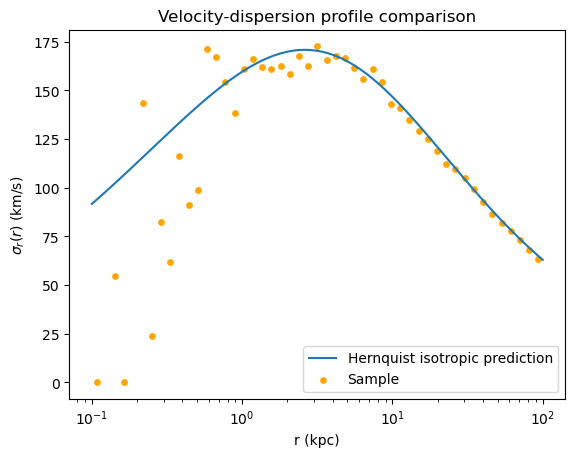

In [20]:
# velocity dispersion σ^2(r) = 1/3(<v^2> - <v>^2), but since it's isotropic <v> = 0

vx = orbits.vx(use_physical=True)
vy = orbits.vy(use_physical=True)
vz = orbits.vz(use_physical=True)

sigma2_sample = np.zeros(len(r_centres))
for i, (r_lo, r_hi) in enumerate(zip(edges[:-1], edges[1:])): # get the inner and outer boundary of each bin
    mask = (r_samples >= r_lo) & (r_samples < r_hi) # make sure each particle is in the bin
    sigma2_sample[i] = (np.var(vx[mask]) + np.var(vy[mask]) + np.var(vz[mask])) / 3.0

sigma_sample = np.sqrt(sigma2_sample) # km/s

# get the analytical velocity dispersion
r_fine_kpc = np.logspace(np.log10(r_min),np.log10(r_max),200)
r_fine_internal = r_fine_kpc / 8.0
sigma_analytic = np.array([hq_df.sigmar(r) for r in r_fine_internal]) 

plt.title("Velocity-dispersion profile comparison")
plt.plot(r_fine_kpc,sigma_analytic, label="Hernquist isotropic prediction")
plt.scatter(r_centres,sigma_sample, color="orange", s=15,label="Sample")
plt.xlabel("r (kpc)")
plt.ylabel("$σ_r(r)$ (km/s)")
plt.xscale("log")
plt.legend()
plt.show()

####4. 

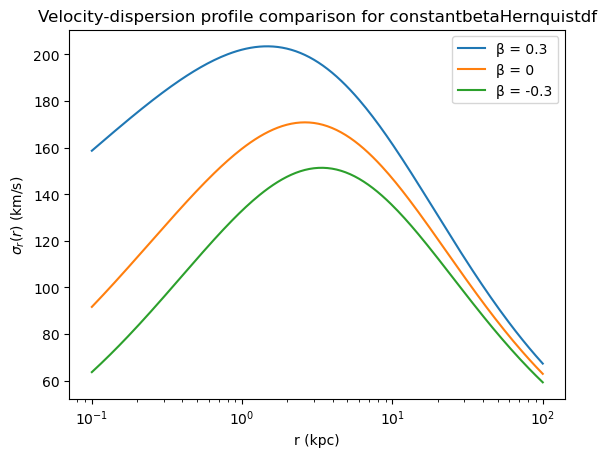

In [21]:
hq_beta_neg = constantbetaHernquistdf(pot=hq_best,beta=-0.3)
sigma_beta_neg = np.array([hq_beta_neg.sigmar(r) for r in r_fine_internal])

hq_beta_pos = constantbetaHernquistdf(pot=hq_best,beta=0.3)
sigma_beta_pos = np.array([hq_beta_pos.sigmar(r) for r in r_fine_internal])

hq_beta_zero = constantbetaHernquistdf(pot=hq_best,beta=0)
sigma_beta_zero = np.array([hq_beta_zero.sigmar(r) for r in r_fine_internal])

plt.title("Velocity-dispersion profile comparison for constantbetaHernquistdf")
plt.xlabel("r (kpc)")
plt.ylabel("$σ_r(r)$ (km/s)")
plt.xscale("log")
plt.plot(r_fine_kpc,sigma_beta_pos,label="β = 0.3")
plt.plot(r_fine_kpc,sigma_beta_zero, label = "β = 0")
plt.plot(r_fine_kpc,sigma_beta_neg,label="β = -0.3")
plt.legend()
plt.show()

The positive beta value increased the velocity dispersion profile, which signifies more radial dispersion, while the positive beta value decreased the velocity dispersion profile, signifying more tangential dispersion. 

##Exercise 5

####1.

In [22]:
N = 2000
stars = hq_df.sample(n=N)
stars.turn_physical_on(ro=ro, vo=vo)
mask = (stars.r(use_physical=False) > r_grid.min()) & \
       (stars.r(use_physical=False) < r_grid.max())
stars = stars[mask]
ts = np.linspace(0., 4., 1000) * u.Gyr
stars.integrate(ts, mw_interp, method="dop853_c")


####2.

In [23]:
# One thread
os.environ["OMP_NUM_THREADS"] = "1"
omp.omp_set_num_threads(1)

start = time.time()
stars.integrate(ts, mw_interp, method="dop853_c")
t1 = time.time() - start

# All available cores
os.environ["OMP_NUM_THREADS"] = "8"
omp.omp_set_num_threads(8)

start = time.time()
stars.integrate(ts, mw_interp, method="dop853_c")
t2 = time.time() - start

speedup = t1 / t2

print(f"Using all available cores was {speedup:.3f} times faster than using one thread.")

Using all available cores was 3.140 times faster than using one thread.


####3.

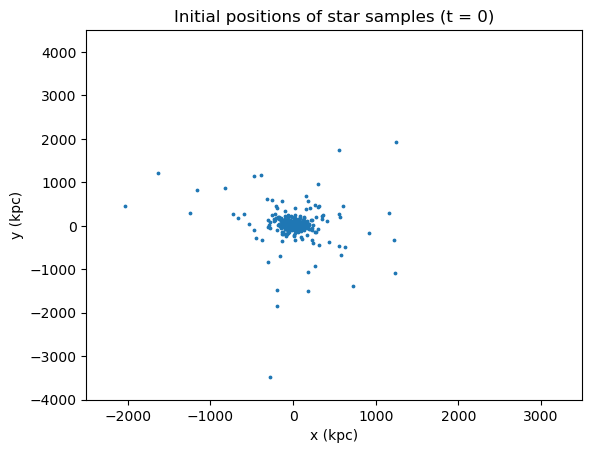

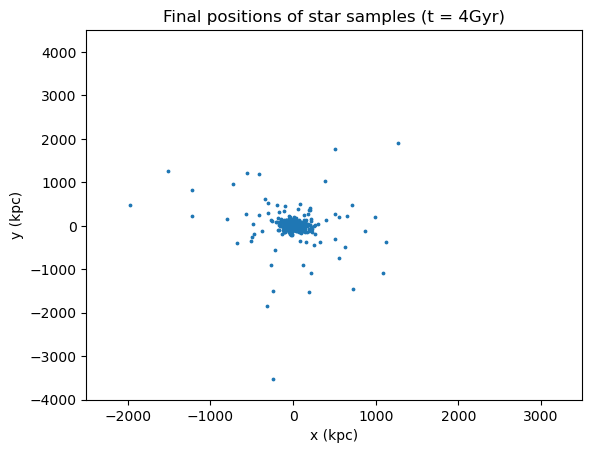

In [24]:
plt.scatter(stars.x(0),stars.y(0),s=3)
plt.xlabel("x (kpc)")
plt.ylabel("y (kpc)")
plt.xlim(-2500,3500)
plt.ylim(-4000,4500)
plt.title("Initial positions of star samples (t = 0)")
plt.show()

plt.scatter(stars.x(ts[-1]),stars.y(ts[-1]),s=3)
plt.xlabel("x (kpc)")
plt.ylabel("y (kpc)")
plt.xlim(-2500,3500)
plt.ylim(-4000,4500)
plt.title("Final positions of star samples (t = 4Gyr)")
plt.show()



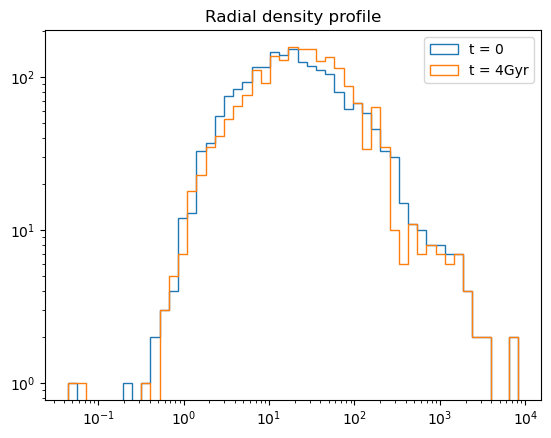

In [25]:
r_initial = stars.r(0)
r_final = stars.r(ts[-1])

bins = np.geomspace(r_initial.min(), r_initial.max(), 50)

plt.hist(r_initial, bins, histtype="step", label = "t = 0")
plt.hist(r_final, bins, histtype="step", label = "t = 4Gyr")

plt.xscale("log")
plt.yscale("log")

plt.title("Radial density profile")
plt.legend()
plt.show()


##Exercise 6

####1.

In [26]:
lmc = HernquistPotential(amp=1.5e11 * u.Msun, a=10 * u.kpc)
o_lmc = Orbit.from_name("LMC")

####2.

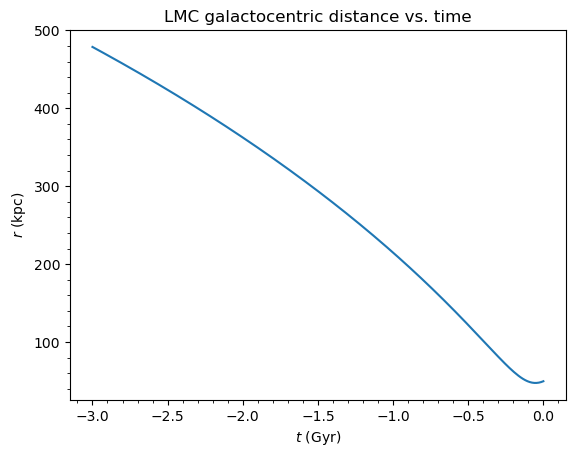

In [27]:
friction = ChandrasekharDynamicalFrictionForce(GMs=1.5e11* u.Msun,sigmar=hq_df.sigmar)
ts_bckwd = np.linspace(0,-3,200)*u.Gyr
o_lmc.integrate(ts_bckwd,[mw_interp,friction],method="dop853_c")

o_lmc.plot(d1='t',d2='r')
plt.title("LMC galactocentric distance vs. time")
plt.show()

####3.

In [28]:
lmc_moving = MovingObjectPotential(o_lmc,pot=lmc)
ts_fwd = np.linspace(-3.,0,200) * u.Gyr

o_lmc.integrate(ts_fwd,[mw_interp,lmc_moving],method="dop853_c")

o_lmc_expected = Orbit.from_name("LMC")

print("Recovered R:",o_lmc.R(ts_bckwd[-1]))
print("Expected R:", o_lmc_expected.R())
print("Recovered vR:", o_lmc.vR(ts_bckwd[-1]))
print("Expected vR:", o_lmc_expected.vR())
print("Recovered vT:",o_lmc.vT(ts_bckwd[-1]))
print("Expected vT:", o_lmc_expected.vT())
print("Recovered z:",o_lmc.z(ts_bckwd[-1]))
print("Expected z:", o_lmc_expected.z())
print("Recovered vz:",o_lmc.vz(ts_bckwd[-1]))
print("Expected vz:", o_lmc_expected.vz())
print("Recovered phi:",o_lmc.phi(ts_bckwd[-1]))
print("Expected phi:", o_lmc_expected.phi())

Recovered R: 41.05600268190307
Expected R: 41.05600268190307
Recovered vR: 237.67271185869794
Expected vR: 237.67271185869794
Recovered vT: 51.31145910655079
Expected vT: 51.31145910655079
Recovered z: -27.845492259796814
Expected z: -27.845492259796814
Recovered vz: 208.89194393199298
Expected vz: 208.89194393199298
Recovered phi: -1.5462609110189092
Expected phi: -1.5462609110189092


####4.

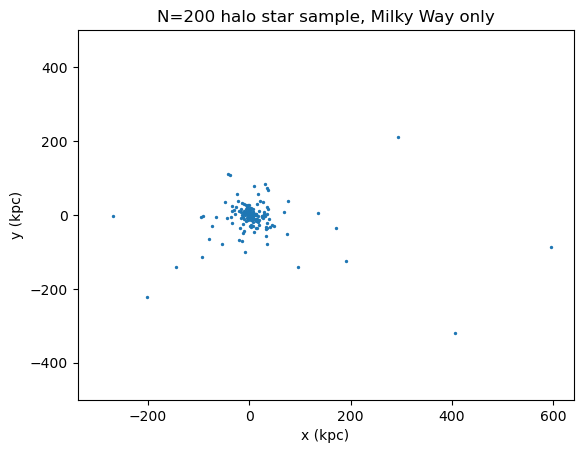

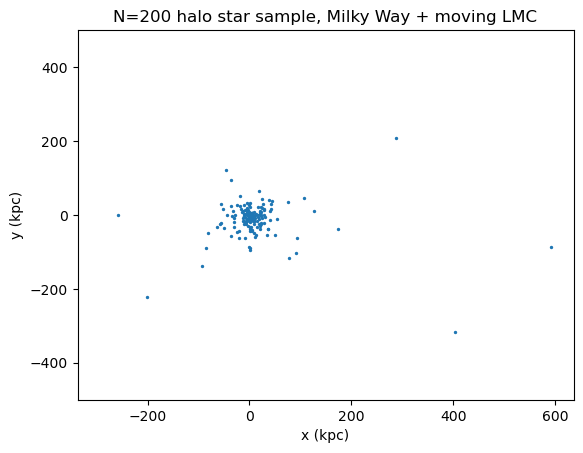

In [45]:
N_small = 200
np.random.seed(0)
stars_unperturbed = hq_df.sample(n=N_small)
mask = (stars_unperturbed.r(use_physical=False) > r_grid.min()) & \
       (stars_unperturbed.r(use_physical=False) < r_grid.max())
stars_unperturbed = stars_unperturbed[mask]
stars_unperturbed.turn_physical_on(ro=ro, vo=vo)

np.random.seed(0)
stars_perturbed = hq_df.sample(n=N_small)
stars_perturbed = stars_perturbed[mask]
stars_perturbed.turn_physical_on(ro=ro, vo=vo)

ts_fwd = np.linspace(0., 3., 2001) * u.Gyr
stars_unperturbed.integrate(ts_fwd, mw_interp, method='dop853_c')
stars_perturbed.integrate(ts_fwd, [mw_interp, lmc_moving])

plt.scatter(stars_unperturbed.x(ts_fwd[-1]), stars_unperturbed.y(ts_fwd[-1]), s=2)
plt.title("N=200 halo star sample, Milky Way only")
plt.xlabel("x (kpc)")
plt.ylabel("y (kpc)")
plt.ylim(-500,500)
plt.show()

plt.scatter(stars_perturbed.x(ts_fwd[-1]), stars_perturbed.y(ts_fwd[-1]), s=2)
plt.title("N=200 halo star sample, Milky Way + moving LMC")
plt.xlabel("x (kpc)")
plt.ylabel("y (kpc)")
plt.ylim(-500,500)
plt.show()

##Exercise 7

####1.

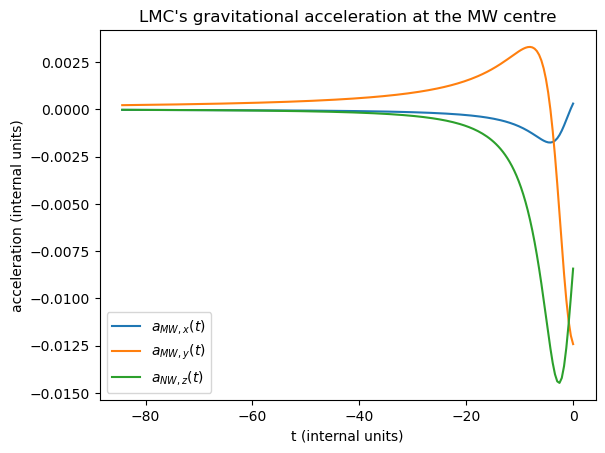

In [48]:
loc_origin = 1e-4

t_galpy = o_lmc.time(use_physical=False)

ax = np.array([evaluateRforces(lmc_moving, loc_origin, 0., phi=0., t=t, use_physical=False) for t in t_galpy])
ay = np.array([evaluatephitorques(lmc_moving, loc_origin, 0., phi=0., t=t, use_physical=False) for t in t_galpy]) / loc_origin
az = np.array([evaluatezforces(lmc_moving, loc_origin, 0., phi=0., t=t, use_physical=False) for t in t_galpy])

plt.plot(t_galpy, ax, label="$a_{MW,x}(t)$")
plt.plot(t_galpy, ay, label="$a_{MW,y}(t)$")
plt.plot(t_galpy, az, label="$a_{NW,z}(t)$")
plt.xlabel("t (internal units)")
plt.ylabel("acceleration (internal units)")
plt.title("LMC's gravitational acceleration at the MW centre")
plt.legend()
plt.show()

####2.

In [43]:
ax_int = lambda t: np.interp(t,t_galpy,ax)
ay_int = lambda t: np.interp(t,t_galpy,ay)
az_int = lambda t: np.interp(t,t_galpy,az)

nif = NonInertialFrameForce(a0=[ax_int,ay_int,az_int])

####3.

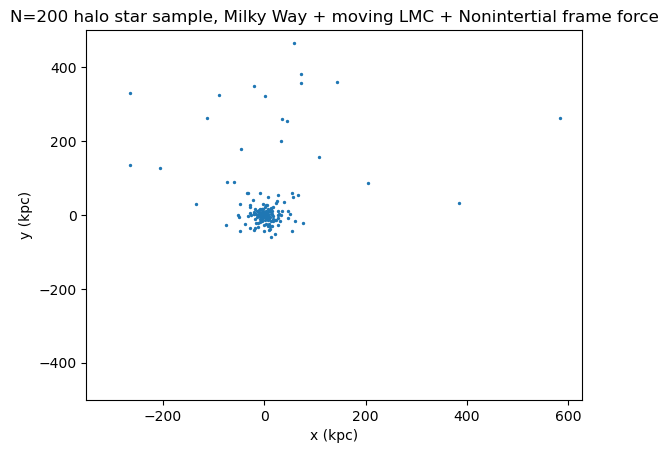

In [44]:
np.random.seed(0)
stars_nif = hq_df.sample(n=N_small)
stars_nif = stars_nif[mask]
stars_nif.turn_physical_on(ro=ro, vo=vo)

stars_nif.integrate(ts_fwd, [mw_interp, lmc_moving, nif])

plt.scatter(stars_nif.x(ts_fwd[-1]), stars_nif.y(ts_fwd[-1]), s=2)
plt.title("N=200 halo star sample, Milky Way + moving LMC + Nonintertial frame force")
plt.xlabel("x (kpc)")
plt.ylabel("y (kpc)")
plt.ylim(-500,500)
plt.show()